In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import resample
import matplotlib.pyplot as plt

In [3]:
braces_area_new = '/Users/matthewng/Downloads/braces_area_classification_filtered.xlsx'
braces_area_new_df = pd.read_excel(braces_area_new)

In [4]:
# Create a derived feature: percentage of detected area
braces_area_new_df["Percentage of Detected Area"] = (braces_area_new_df["Brace area"] / braces_area_new_df["Total area"]) * 100

# Separate majority and minority classes
braces_area_new_df_majority = braces_area_new_df[braces_area_new_df["Is case?"] == 1]
braces_area_new_df_minority = braces_area_new_df[braces_area_new_df["Is case?"] == 0]

# Undersample the majority class to match the minority class size
df_majority_downsampled = resample(braces_area_new_df_majority,
                                   replace=False,
                                   n_samples=len(braces_area_new_df_minority),
                                   random_state=42)

# Combine to form a balanced dataset
df_balanced = pd.concat([df_majority_downsampled, braces_area_new_df_minority])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Show class distribution after balancing
df_balanced["Is case?"].value_counts()

# Show class distribution after balancing
df_balanced["Is case?"].value_counts()

# Define features (X), labels (y), and filenames
X = df_balanced[['Brace area', 'Percentage of Detected Area']]
y = df_balanced['Is case?']
# Split with filenames included
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [5]:
# Count how many 0s and 1s are in the labels
label_counts = pd.Series(y).value_counts()
print("Label counts:\n", label_counts)

Label counts:
 Is case?
1    135
0    135
Name: count, dtype: int64


Training Accuracy: 0.9752
Testing Accuracy: 0.9853
Cross-validation Accuracy: 0.9754 ± 0.0154
Training Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        98
           1       1.00      0.95      0.98       104

    accuracy                           0.98       202
   macro avg       0.98      0.98      0.98       202
weighted avg       0.98      0.98      0.98       202

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        37
           1       1.00      0.97      0.98        31

    accuracy                           0.99        68
   macro avg       0.99      0.98      0.99        68
weighted avg       0.99      0.99      0.99        68



/Users/matthewng/PycharmProjects/rna_mod_prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/matthewng/PycharmProjects/rna_mod_prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/matthewng/PycharmProjects/rna_mod_prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/matthewng/PycharmProjects/rna_mod_prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/matthewng/PycharmProjects/rna_mod_prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag

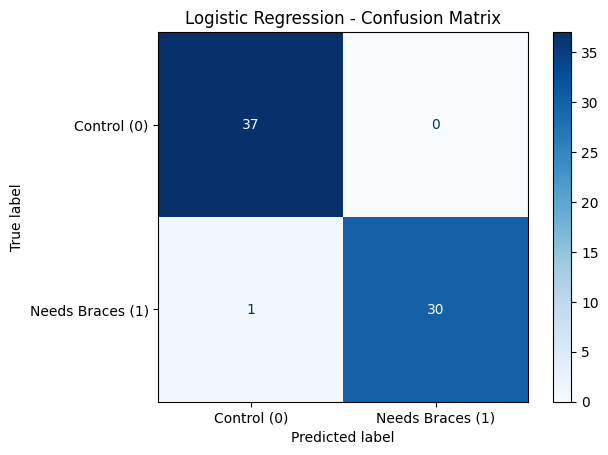

In [6]:
# Logistic Regression

lr_model = LogisticRegression(C=10, penalty='l1', solver='saga', class_weight='balanced')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred_lr)
report = classification_report(y_test, y_pred_lr)

train_accuracy_lr = lr_model.score(X_train_scaled, y_train)
test_accuracy_lr = lr_model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy_lr:.4f}")
print(f"Testing Accuracy: {test_accuracy_lr:.4f}")

train_pred_lr = lr_model.predict(X_train_scaled)
test_pred_lr = lr_model.predict(X_test_scaled)

cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring="accuracy")
print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("Training Classification Report:")
print(classification_report(y_train, train_pred_lr))

print("Testing Classification Report:")
print(classification_report(y_test, test_pred_lr))

lr_conf_matrix = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=lr_conf_matrix,
                              display_labels=["Control (0)", "Needs Braces (1)"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Logistic Regression - Confusion Matrix")
plt.grid(False)
plt.show()

Training Accuracy: 0.9752
Testing Accuracy: 1.0000
Cross-validation Accuracy: 0.9754 ± 0.0154
Training Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        98
           1       1.00      0.95      0.98       104

    accuracy                           0.98       202
   macro avg       0.98      0.98      0.98       202
weighted avg       0.98      0.98      0.98       202

Testing Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00        31

    accuracy                           1.00        68
   macro avg       1.00      1.00      1.00        68
weighted avg       1.00      1.00      1.00        68



/Users/matthewng/PycharmProjects/rna_mod_prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/matthewng/PycharmProjects/rna_mod_prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/matthewng/PycharmProjects/rna_mod_prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/matthewng/PycharmProjects/rna_mod_prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/matthewng/PycharmProjects/rna_mod_prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag

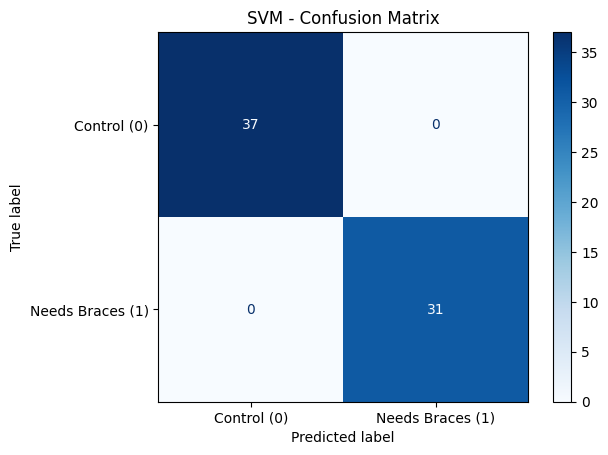

In [7]:
# SVM model

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


selector = SelectKBest(score_func=f_classif, k='all')  # or pick top 'k'
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)
svm_model = SVC(kernel = 'rbf', C = 100, class_weight='balanced', gamma = 0.1, random_state=42, probability=True)
svm_model.fit(X_train_selected, y_train)

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test_selected)
y_prob_svm = svm_model.predict_proba(X_test_selected)[:, 1]

# Evaluate the SVM Model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
report_svm = classification_report(y_test, y_pred_svm)

train_pred_svm = svm_model.predict(X_train_selected)
test_pred_svm = svm_model.predict(X_test_selected)

train_accuracy_svm = svm_model.score(X_train_selected, y_train)
test_accuracy_svm = svm_model.score(X_test_selected, y_test)

print(f"Training Accuracy: {train_accuracy_svm:.4f}")
print(f"Testing Accuracy: {test_accuracy_svm:.4f}")

cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring="accuracy")
print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("Training Classification Report:")
print(classification_report(y_train, train_pred_svm))

print("Testing Classification Report:")
print(classification_report(y_test, test_pred_svm))

svm_conf_matrix = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=svm_conf_matrix,
                              display_labels=["Control (0)", "Needs Braces (1)"])
disp.plot(cmap="Blues", values_format="d")
plt.title("SVM - Confusion Matrix")
plt.grid(False)
plt.show()

Training Accuracy: 1.0000
Testing Accuracy: 1.0000
Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        98
           1       1.00      1.00      1.00       104

    accuracy                           1.00       202
   macro avg       1.00      1.00      1.00       202
weighted avg       1.00      1.00      1.00       202

Testing Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00        31

    accuracy                           1.00        68
   macro avg       1.00      1.00      1.00        68
weighted avg       1.00      1.00      1.00        68

Cross-validation Accuracy: 1.0000 ± 0.0000


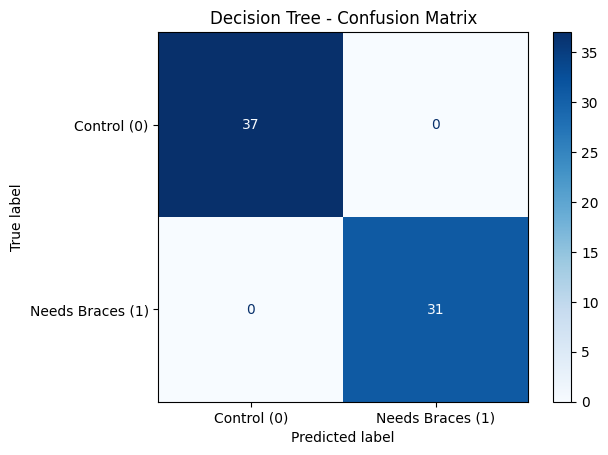

In [8]:
# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=None, min_samples_split=10, min_samples_leaf=4, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
dt_model.fit(X_train_scaled, y_train)


# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test_scaled)
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the Decision Tree model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
report_dt = classification_report(y_test, y_pred_dt)

train_accuracy_dt = dt_model.score(X_train_scaled, y_train)
test_accuracy_dt = dt_model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy_dt:.4f}")
print(f"Testing Accuracy: {test_accuracy_dt:.4f}")

train_pred_dt = dt_model.predict(X_train_scaled)
test_pred_dt = dt_model.predict(X_test_scaled)

print("Training Classification Report:")
print(classification_report(y_train, train_pred_dt))

print("Testing Classification Report:")
print(classification_report(y_test, test_pred_dt))

cv_scores = cross_val_score(dt_model, X_train_scaled, y_train, cv=5, scoring="accuracy")
print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

dt_conf_matrix = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=dt_conf_matrix,
                              display_labels=["Control (0)", "Needs Braces (1)"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Decision Tree - Confusion Matrix")
plt.grid(False)
plt.show()


Training Accuracy: 1.0000
Testing Accuracy: 1.0000
Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        98
           1       1.00      1.00      1.00       104

    accuracy                           1.00       202
   macro avg       1.00      1.00      1.00       202
weighted avg       1.00      1.00      1.00       202

Testing Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00        31

    accuracy                           1.00        68
   macro avg       1.00      1.00      1.00        68
weighted avg       1.00      1.00      1.00        68



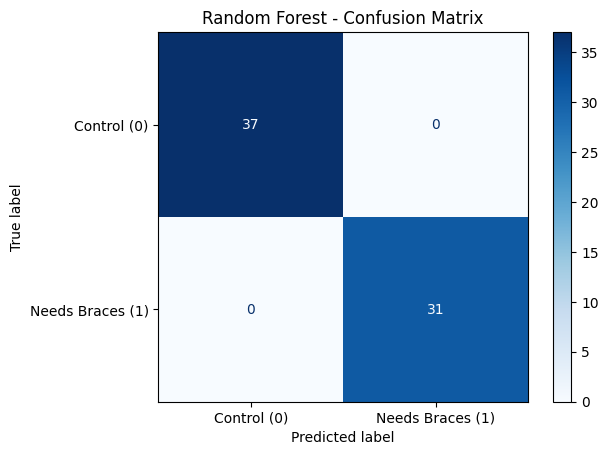

In [9]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=2, min_samples_split=10, bootstrap=False, random_state=42, class_weight='balanced')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
rf_model.fit(X_train_scaled, y_train)


# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)

train_accuracy_rf = rf_model.score(X_train_scaled, y_train)
test_accuracy_rf = rf_model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy_rf:.4f}")
print(f"Testing Accuracy: {test_accuracy_rf:.4f}")

train_pred_rf = rf_model.predict(X_train_scaled)
test_pred_rf = rf_model.predict(X_test_scaled)

print("Training Classification Report:")
print(classification_report(y_train, train_pred_rf))

print("Testing Classification Report:")
print(classification_report(y_test, test_pred_rf))

rf_conf_matrix = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=rf_conf_matrix,
                              display_labels=["Control (0)", "Needs Braces (1)"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Random Forest - Confusion Matrix")
plt.grid(False)
plt.show()

Training Accuracy: 0.9901
Testing Accuracy: 1.0000
Training Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        98
           1       1.00      0.98      0.99       104

    accuracy                           0.99       202
   macro avg       0.99      0.99      0.99       202
weighted avg       0.99      0.99      0.99       202

Testing Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00        31

    accuracy                           1.00        68
   macro avg       1.00      1.00      1.00        68
weighted avg       1.00      1.00      1.00        68



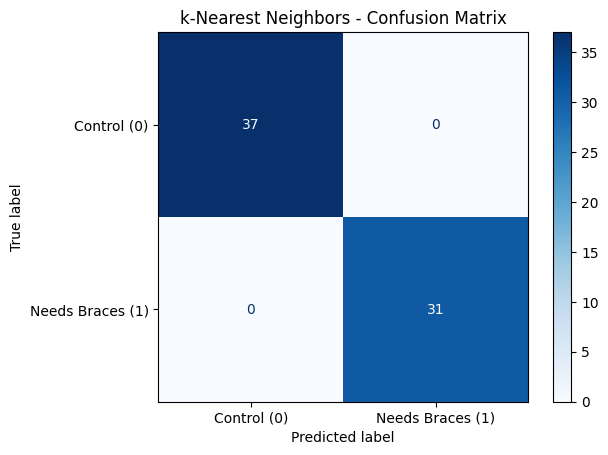

In [10]:
# KNN model

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a K-Nearest Neighbors (KNN) model
knn_model = KNeighborsClassifier(metric= 'euclidean', n_neighbors=7, weights= 'uniform')  # Using 5 neighbors as default
knn_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the KNN model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
report_knn = classification_report(y_test, y_pred_knn)

train_pred_knn = knn_model.predict(X_train_scaled)
test_pred_knn = knn_model.predict(X_test_scaled)

train_accuracy_knn = knn_model.score(X_train_scaled, y_train)
test_accuracy_knn = knn_model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy_knn:.4f}")
print(f"Testing Accuracy: {test_accuracy_knn:.4f}")

print("Training Classification Report:")
print(classification_report(y_train, train_pred_knn))

print("Testing Classification Report:")
print(classification_report(y_test, test_pred_knn))

knn_conf_matrix = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=knn_conf_matrix,
                              display_labels=["Control (0)", "Needs Braces (1)"])
disp.plot(cmap="Blues", values_format="d")
plt.title("k-Nearest Neighbors - Confusion Matrix")
plt.grid(False)
plt.show()


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
)


Logistic Regression Model Evaluation:
Accuracy: 0.9852941176470589
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99        37
           1       1.00      0.97      0.98        31

    accuracy                           0.99        68
   macro avg       0.99      0.98      0.99        68
weighted avg       0.99      0.99      0.99        68

Confusion Matrix:
[[37  0]
 [ 1 30]]
AUC: 1.0000

Decision Tree Model Evaluation:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00        31

    accuracy                           1.00        68
   macro avg       1.00      1.00      1.00        68
weighted avg       1.00      1.00      1.00        68

Confusion Matrix:
[[37  0]
 [ 0 31]]
AUC: 1.0000

Random Forest Model Evaluation:
Accuracy: 1.0
Classification Report:
               

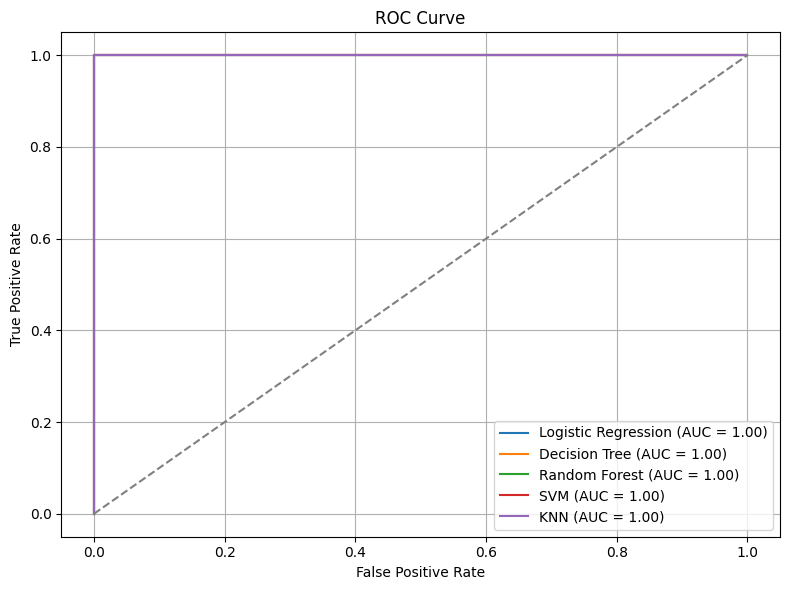

In [13]:
# Compute evaluation metrics
def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n{name} Model Evaluation:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    auc = roc_auc_score(y_true, y_prob)
    print(f"AUC: {auc:.4f}")
    return auc

auc_lr = evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr)
auc_dt = evaluate_model("Decision Tree", y_test, y_pred_dt, y_prob_dt)
auc_rf = evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)
auc_svm = evaluate_model("SVM", y_test, y_pred_svm, y_prob_svm)
auc_knn = evaluate_model("KNN", y_test, y_pred_knn, y_prob_knn)


# Plot ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.2f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("models_roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()

In [14]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

def plot_learning_curve(estimator, X, y, title="", cv=None, scoring='accuracy'):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5), shuffle=True, random_state=42
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    plt.plot(train_sizes, train_mean, 'o-', label='Training score')
    # plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)

    plt.plot(train_sizes, val_mean, 'o-', label='Cross-validation score')
    # plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1)

    plt.title(title)
    plt.xlabel("Training Set Size")
    plt.ylabel("Accuracy")
    plt.legend(loc="best")
    plt.grid(True)

In [15]:
# Example classifiers and matching training data
classifiers = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "SVM": svm_model,
    "KNN": knn_model
}

# Corresponding training data for each model
model_train_data = {
    "Logistic Regression": X_train_scaled,
    "Decision Tree": X_train_scaled,
    "Random Forest": X_train_selected,
    "SVM": X_train_scaled,
    "KNN": X_train_scaled
}

/Users/matthewng/PycharmProjects/rna_mod_prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/matthewng/PycharmProjects/rna_mod_prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/matthewng/PycharmProjects/rna_mod_prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/matthewng/PycharmProjects/rna_mod_prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/matthewng/PycharmProjects/rna_mod_prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag

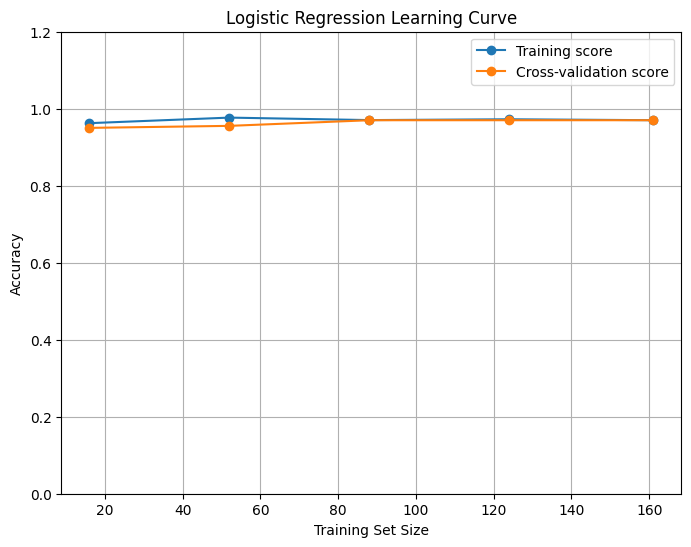

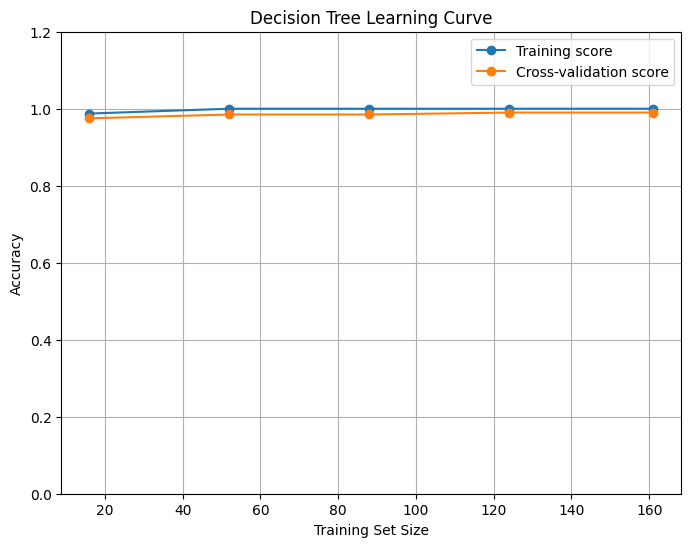

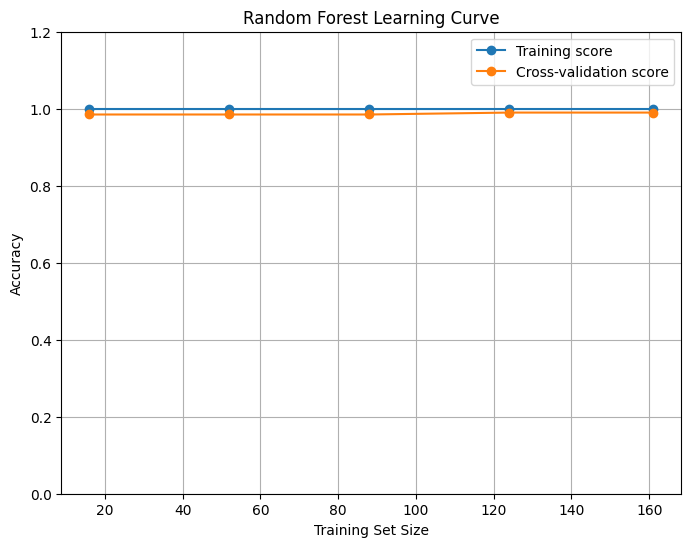

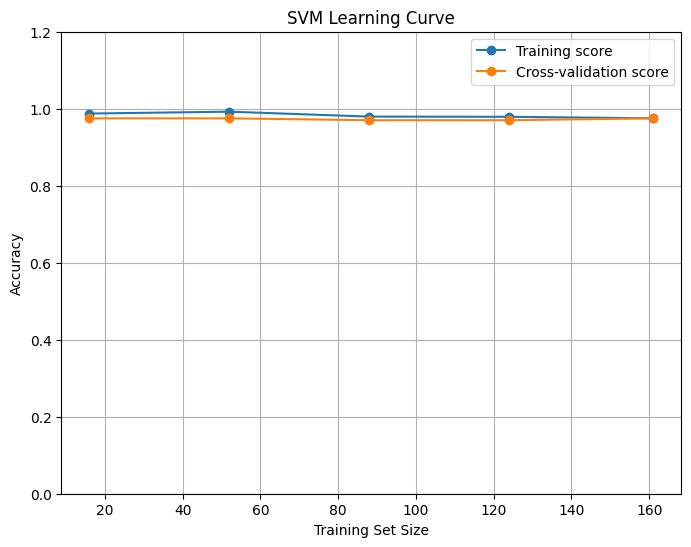

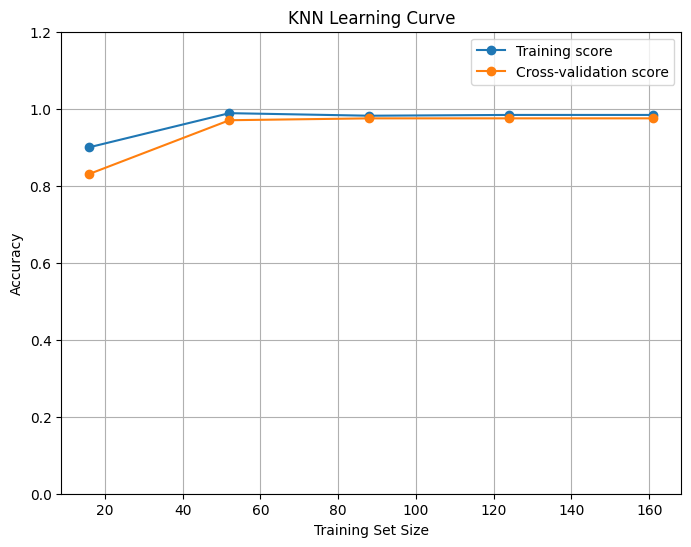

In [16]:
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in classifiers.items():
    X_model_train = model_train_data[name]  # Get the right X_train for each model

    plt.figure(figsize=(8, 6))
    plot_learning_curve(model, X_model_train, y_train, title=f"{name} Learning Curve", cv=cv)




    plt.ylim(0, 1.0)  # Force y-axis to go from 0 to 1
    plt.yticks(np.arange(0, 1.4, 0.2))  # Ticks: 0.0, 0.2, ..., 1.0

    plt.grid(True)
    filename = f"{name.replace(' ', '_').lower()}_learning_curve.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()




Building an ensemble of top models (Logistic Regression, Random Forest, SVM)...
Ensemble (Tuned Models) Evaluation Metrics:
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00        31

    accuracy                           1.00        68
   macro avg       1.00      1.00      1.00        68
weighted avg       1.00      1.00      1.00        68



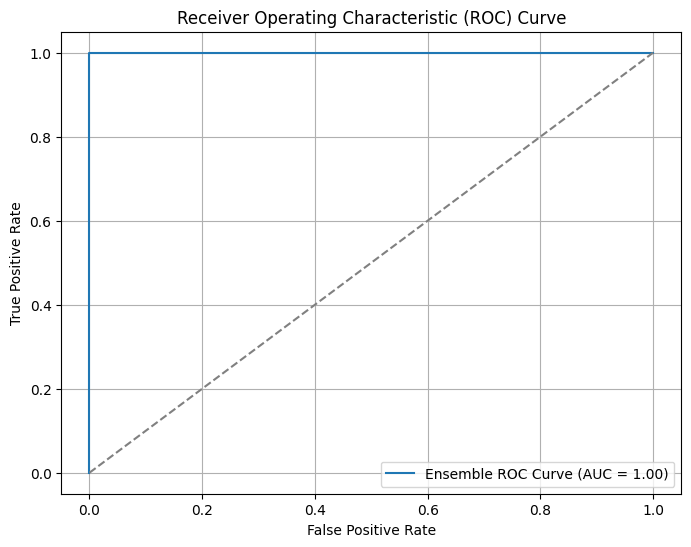

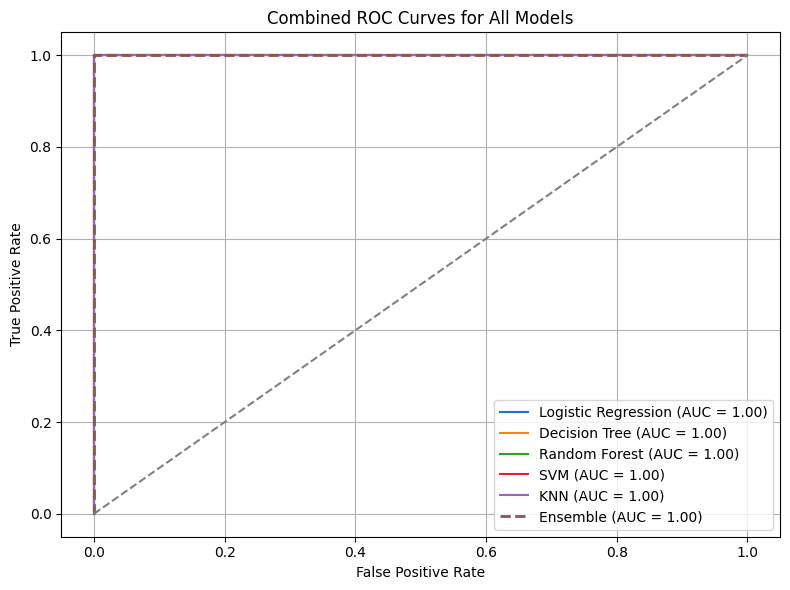

In [17]:
# %% [code]
print("\nBuilding an ensemble of top models (Logistic Regression, Random Forest, SVM)...")

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.ensemble import VotingClassifier

log_clf = lr_model
dt_clf = dt_model
rf_clf = rf_model
svm_clf = svm_model
knn_clf = knn_model  # Needed for soft voting

# We'll combine three top-performing models based on your earlier results:
voting_clf = VotingClassifier(
    estimators=[
        #    ('lr', log_clf),
        ('dt', dt_clf),
        ('rf', rf_clf),
        #    ('svm', svm_clf),
        #    ('knn', knn_clf)
    ],
    voting='soft',  # or 'hard'
    weights=[1, 1]
)
# 'soft' averages predicted probabilities

voting_clf.fit(X_train_scaled, y_train)
y_pred_ensemble_tuned = voting_clf.predict(X_test_scaled)

# Calculate evaluation metrics
acc = accuracy_score(y_test, y_pred_ensemble_tuned)
prec = precision_score(y_test, y_pred_ensemble_tuned)
rec = recall_score(y_test, y_pred_ensemble_tuned)
f1 = f1_score(y_test, y_pred_ensemble_tuned)

print("Ensemble (Tuned Models) Evaluation Metrics:")
print(f"Accuracy: {acc:.2f}")
print(f"Precision: {prec:.2f}")
print(f"Recall: {rec:.2f}")
print(f"F1 Score: {f1:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ensemble_tuned))
y_proba_ensemble = voting_clf.predict_proba(X_test_scaled)[:, 1]  # Probability for class 1

fpr, tpr, thresholds = roc_curve(y_test, y_proba_ensemble)
auc_score = roc_auc_score(y_test, y_proba_ensemble)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Ensemble ROC Curve (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.grid(True)
plt.savefig("ensemble_roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()

# Also compute and plot ensemble ROC here
fpr_ensemble, tpr_ensemble, _ = roc_curve(y_test, y_proba_ensemble)
auc_ensemble = roc_auc_score(y_test, y_proba_ensemble)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.2f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.2f})')
plt.plot(fpr_ensemble, tpr_ensemble, label=f'Ensemble (AUC = {auc_ensemble:.2f})', linewidth=2, linestyle='--')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.title('Combined ROC Curves for All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig("combined_roc_all_models.png", dpi=300, bbox_inches='tight')
plt.show()


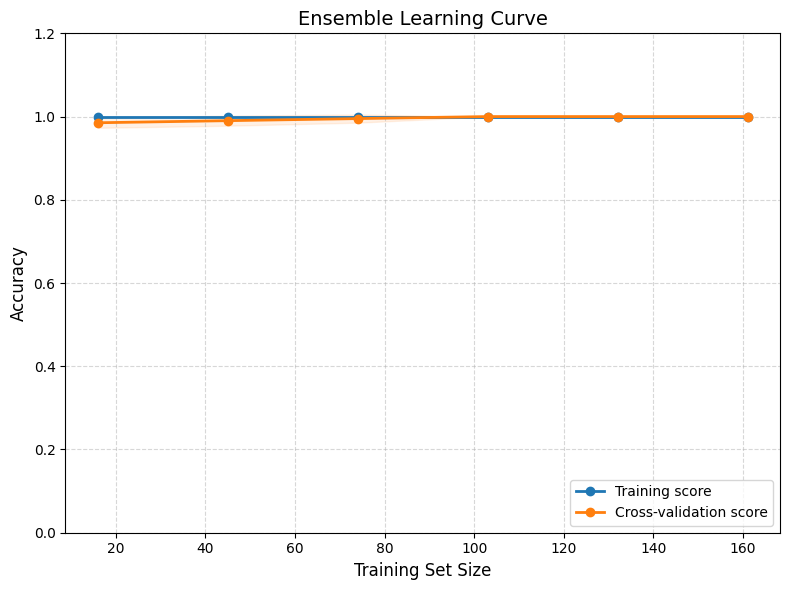

In [19]:
train_sizes, train_scores, test_scores = learning_curve(
    voting_clf,                  # your ensemble model
    X_train_scaled, y_train,     # training data
    cv=5,                        # 5-fold cross-validation
    scoring='accuracy',          # you can change to 'f1' or 'roc_auc'
    n_jobs=-1,                   # parallel processing
    train_sizes=np.linspace(0.1, 1.0, 6),  # 6 points from 10% to 100%
    shuffle=True,
    random_state=42
)

# Compute means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# --- Plot ---
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#1f77b4', label='Training score', linewidth=2, markersize=6)
plt.plot(train_sizes, test_mean, 'o-', color='#ff7f0e', label='Cross-validation score', linewidth=2, markersize=6)

# Fill ±1 std deviation areas
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.1, color='#1f77b4')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                 alpha=0.1, color='#ff7f0e')

plt.title("Ensemble Learning Curve", fontsize=14)
plt.xlabel("Training Set Size", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0.0, 1.2)  # same scaling as your example
plt.legend(fontsize=10, loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
